# Альфа-Банк × МФТИ — «Отклик на кредитный оффер»

**Задача.** Бинарная классификация: предсказать вероятность того, что корпоративный клиент
согласится на предложенный оффер по овердрафту (`target_value`). **Метрика — ROC-AUC.**

**Ключевые особенности данных** (определяют стратегию):
- сильный дисбаланс классов (~6 % положительных);
- **временной сплит**: train = 2024-02 … 2025-06-05, test — будущее (2025-06 … 2025-12) →
  валидация строится по времени (не случайный K-fold);
- шаблон сабмита содержит 45 032 id = 36 311 из test **+ 8 721 id, лежащих в train**
  (их метки известны) → для них подставляем истинные метки, для test — предсказания модели;
- признаки анонимизированы/масштабированы → градиентный бустинг, без ручного скейлинга;
- много структурированных пропусков → факт пропуска кодируем как отдельный признак.

**План ноутбука:** загрузка → EDA/анализ взаимосвязей → feature engineering →
time-aware валидация → LightGBM + CatBoost + XGBoost + ранговый ансамбль → сборка сабмита и проверки.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score
from scipy.stats import rankdata

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

RANDOM_STATE = 42
ID, TARGET, DATE = "front_id", "target_value", "decision_day"
CAT_COLS = ["db_group_last", "fl_adminarea"]
HOLDOUT_START = "2025-03-01"   # последние ~3 месяца train -> временной holdout
DATASET_START = "2024-02-01"

## 1. Загрузка данных

In [2]:
train = pd.read_csv("train_apps.csv", parse_dates=[DATE])
test = pd.read_csv("test_apps.csv", parse_dates=[DATE])
sample = pd.read_csv("sample_submission.csv")
print("train:", train.shape, "| test:", test.shape, "| sample_submission:", sample.shape)
print(f"Доля положительного класса в train: {train[TARGET].mean():.4f}")
print("Период train:", train[DATE].min().date(), "→", train[DATE].max().date())
print("Период test: ", test[DATE].min().date(), "→", test[DATE].max().date())
train.head()

train: (145241, 28) | test: (36311, 27) | sample_submission: (45032, 2)
Доля положительного класса в train: 0.0609
Период train: 2024-02-01 → 2025-06-05
Период test:  2025-06-05 → 2025-12-01


,front_id,decision_day,loan_amount_last,overdraft_limit_min,overdraft_limit_max,offered_rate,cb_rate,corp_credit_products,sum_deb_ul_90,sum_deb_ul_30,cnt_deb_loan_90,cnt_deb_ul_ip_90,cnt_deb_ul_ip_30,balance_rur_amt_30_min,cnt_cred_loan_90,loan_rev_max_start_non_fin,loan_rev_min_start_fin,app_term_mean_360,overdraft_app_term_max_360,days_from_authperson_registration,fl_hdb_bki_total_active_products,corp_list,count_all_corp_dashboard_events,p75_time_spent_minutes,sum_deb_investment_90,db_group_last,fl_adminarea,target_value
0,127345,2024-02-01,1.339991,-1.847954,-1.586546,1.774424,-0.400695,NaN,NaN,NaN,NaN,NaN,NaN,-5.561599,NaN,NaN,NaN,1.767094,NaN,NaN,NaN,NaN,NaN,NaN,NaN,lombard,NaN,0
1,127209,2024-02-01,-2.808489,-3.155914,-2.618329,1.774424,-0.400695,0.842771,NaN,NaN,0.000000,-4.466656,-0.736050,1.466815,0.000000,NaN,NaN,-0.504888,NaN,NaN,NaN,-0.862289,-3.400318,-0.780786,NaN,inn_scoring,NaN,0
2,272776,2024-02-01,2.185431,3.167063,2.369547,-0.709770,-0.400695,0.000000,0.834373,4.897257,0.000000,5.291707,0.872047,4.041974,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.168810,3.015012,0.554064,NaN,NaN,NaN,0
3,127210,2024-02-01,-1.468500,-2.595950,-2.176602,1.774424,-0.400695,NaN,NaN,NaN,NaN,NaN,NaN,-3.322507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,164500,2024-02-01,0.845440,4.559196,3.467730,-2.484194,-0.400695,0.000000,-0.518122,-3.435251,2.999207,-1.373655,-0.118673,4.324315,6.729738,NaN,NaN,NaN,NaN,1.067447,NaN,1.022327,1.506380,0.190096,NaN,NaN,NaN,0


## 2. EDA: анализ взаимосвязей

Цель раздела — понять структуру данных и связь признаков с фактом согласия клиента.

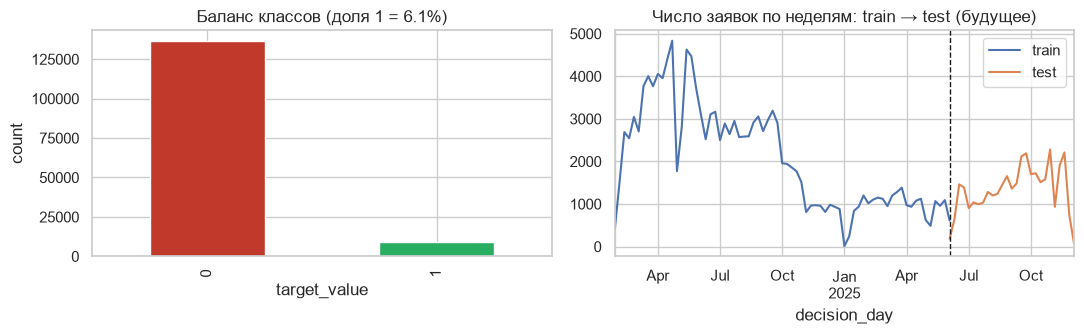

In [3]:
# --- баланс классов ---
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
train[TARGET].value_counts().plot.bar(ax=ax[0], color=["#c0392b", "#27ae60"])
ax[0].set_title(f"Баланс классов (доля 1 = {train[TARGET].mean():.1%})")
ax[0].set_xlabel("target_value"); ax[0].set_ylabel("count")

# --- временное распределение train vs test ---
train.set_index(DATE).resample("W").size().plot(ax=ax[1], label="train")
test.set_index(DATE).resample("W").size().plot(ax=ax[1], label="test")
ax[1].axvline(pd.Timestamp("2025-06-05"), color="k", ls="--", lw=1)
ax[1].set_title("Число заявок по неделям: train → test (будущее)")
ax[1].legend(); plt.tight_layout(); plt.show()

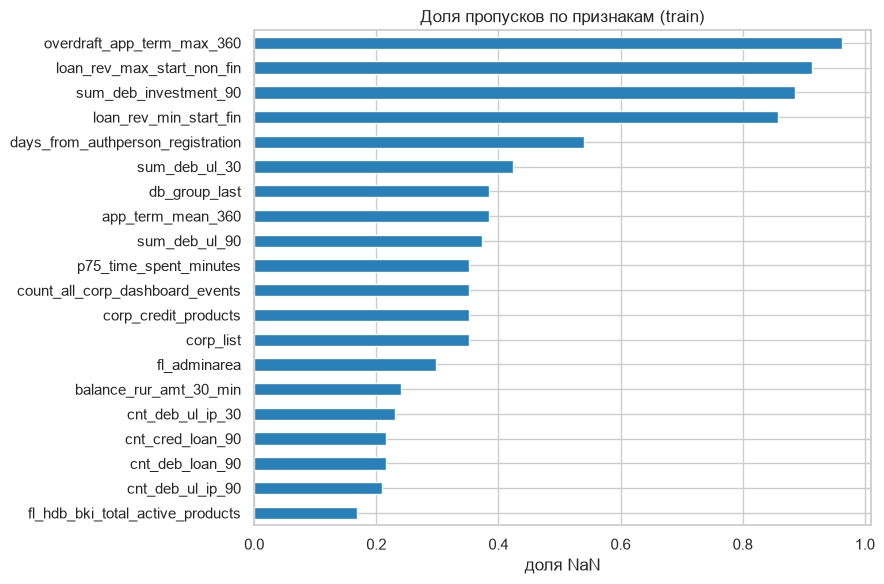

Группы колонок с одинаковым числом пропусков (общий источник данных):
        n_columns
51188           4
31458           2
55883           2
54111           1
61453           1
30305           1
33373           1
34826           1
132635          1
124706          1
139732          1
78473           1
24368           1
128697          1
43310           1


In [4]:
# --- карта пропусков: доля NaN по признакам ---
na = train.isna().mean().sort_values(ascending=False)
na = na[na > 0]
plt.figure(figsize=(9, 6))
na.plot.barh(color="#2980b9")
plt.gca().invert_yaxis()
plt.title("Доля пропусков по признакам (train)")
plt.xlabel("доля NaN"); plt.tight_layout(); plt.show()
print("Группы колонок с одинаковым числом пропусков (общий источник данных):")
print(train.isna().sum()[train.isna().sum() > 0].value_counts().rename("n_columns").to_frame())

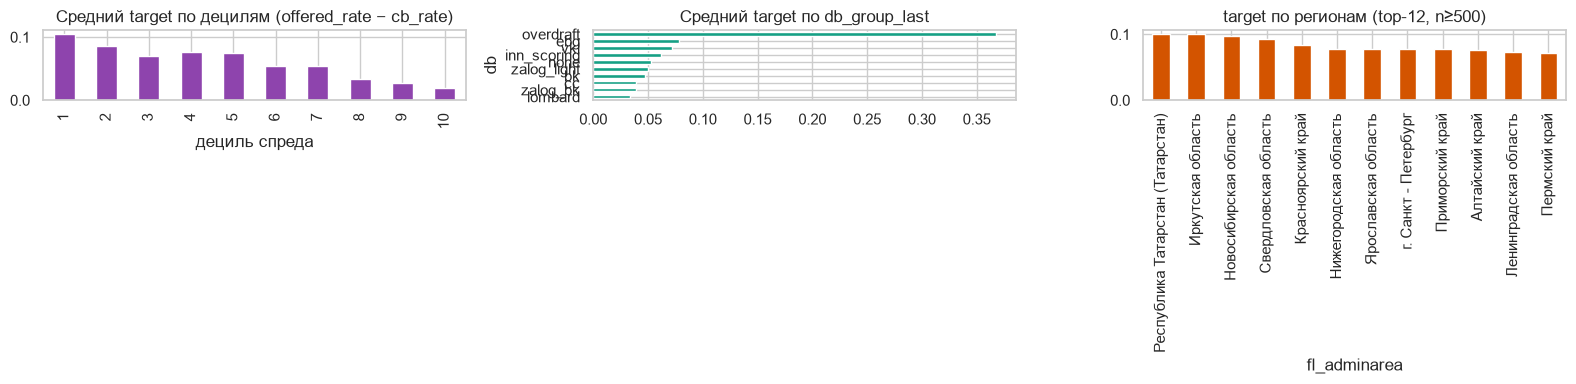

In [5]:
# --- связь признаков с таргетом ---
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

# 1) спред offered_rate - cb_rate
tmp = train.assign(rate_spread=train["offered_rate"] - train["cb_rate"])
tmp["bin"] = pd.qcut(tmp["rate_spread"], 10, duplicates="drop")
tmp.groupby("bin", observed=True)[TARGET].mean().plot.bar(ax=ax[0], color="#8e44ad")
ax[0].set_title("Средний target по децилям (offered_rate − cb_rate)")
ax[0].set_xlabel("дециль спреда"); ax[0].set_xticklabels(range(1, ax[0].get_xticks().size + 1))

# 2) по типу последнего продукта
g = train.assign(db=train["db_group_last"].fillna("none")).groupby("db")[TARGET].agg(["mean", "size"])
g = g.sort_values("mean")
g["mean"].plot.barh(ax=ax[1], color="#16a085")
ax[1].set_title("Средний target по db_group_last")

# 3) топ регионов по объёму
gr = train.groupby("fl_adminarea")[TARGET].agg(["mean", "size"])
gr = gr[gr["size"] >= 500].sort_values("mean", ascending=False).head(12)
gr["mean"].plot.bar(ax=ax[2], color="#d35400")
ax[2].set_title("target по регионам (top-12, n≥500)")
ax[2].set_xlabel("fl_adminarea")
plt.tight_layout(); plt.show()

In [6]:
# --- проверка структуры сабмита ---
sub_ids, test_ids, train_ids = set(sample[ID]), set(test[ID]), set(train[ID])
print("Всего id в шаблоне сабмита:", len(sub_ids))
print("  из них в test:           ", len(sub_ids & test_ids))
print("  из них в train (overlap):", len(sub_ids & train_ids))
print("  ни там, ни там:          ", len(sub_ids - test_ids - train_ids))
ov = train[train[ID].isin(sub_ids & train_ids)]
print("Период overlap-строк в train:", ov[DATE].min().date(), "→", ov[DATE].max().date())

Всего id в шаблоне сабмита: 45032
  из них в test:            36311
  из них в train (overlap): 8721
  ни там, ни там:           0
Период overlap-строк в train: 2025-04-01 → 2025-06-05


**Выводы EDA.** Класс сильно несбалансирован (~6 %), но для ROC-AUC ресэмплинг не требуется.
Test — это будущий период, поэтому валидацию строим по времени. Пропуски структурированы
(группы колонок пропадают вместе) — кодируем факт пропуска. Видна связь таргета со спредом
ставки, типом продукта и регионом. 8 721 строки шаблона сабмита лежат в train (последний срез
2025-04…2025-06) — для них подставим известные метки.

## 3. Feature engineering

Единая функция `build_features`, применяемая одинаково к train и test.

In [7]:
def build_features(df):
    df = df.copy()
    # структура ставки
    df["rate_spread"] = df["offered_rate"] - df["cb_rate"]
    df["rate_ratio"] = df["offered_rate"] / df["cb_rate"].replace(0, np.nan)
    # коридор лимита овердрафта vs запрошенная сумма
    df["band_width"] = df["overdraft_limit_max"] - df["overdraft_limit_min"]
    df["loan_in_band_pos"] = (df["loan_amount_last"] - df["overdraft_limit_min"]) / df["band_width"].replace(0, np.nan)
    df["loan_to_max"] = df["loan_amount_last"] / df["overdraft_limit_max"].replace(0, np.nan)
    df["loan_to_min"] = df["loan_amount_last"] / df["overdraft_limit_min"].replace(0, np.nan)
    df["loan_within_band"] = ((df["loan_amount_last"] >= df["overdraft_limit_min"]) &
                              (df["loan_amount_last"] <= df["overdraft_limit_max"])).astype(int)
    # интенсивность свежей vs длинной активности
    df["deb_ul_30_90_ratio"] = df["sum_deb_ul_30"] / df["sum_deb_ul_90"].replace(0, np.nan)
    df["cnt_ul_ip_30_90_ratio"] = df["cnt_deb_ul_ip_30"] / df["cnt_deb_ul_ip_90"].replace(0, np.nan)
    # временные признаки
    dd = df[DATE]
    df["dd_month"] = dd.dt.month
    df["dd_quarter"] = dd.dt.quarter
    df["dd_dow"] = dd.dt.dayofweek
    df["dd_day"] = dd.dt.day
    df["dd_days_from_start"] = (dd - pd.Timestamp(DATASET_START)).dt.days
    # пропуск как сигнал
    na_flag_cols = ["corp_credit_products", "sum_deb_ul_90", "sum_deb_ul_30",
                    "loan_rev_max_start_non_fin", "loan_rev_min_start_fin",
                    "overdraft_app_term_max_360", "days_from_authperson_registration",
                    "sum_deb_investment_90", "db_group_last", "fl_adminarea",
                    "app_term_mean_360", "balance_rur_amt_30_min"]
    for c in na_flag_cols:
        df[f"isna_{c}"] = df[c].isna().astype(int)
    df["has_corp_dashboard"] = df["count_all_corp_dashboard_events"].notna().astype(int)
    return df.replace([np.inf, -np.inf], np.nan)


train_fe = build_features(train)
test_fe = build_features(test)

# согласованные коды категорий по объединению train+test
for c in CAT_COLS:
    cats = pd.concat([train_fe[c], test_fe[c]]).fillna("none").astype("category").cat.categories
    train_fe[c] = pd.Categorical(train_fe[c].fillna("none"), categories=cats)
    test_fe[c] = pd.Categorical(test_fe[c].fillna("none"), categories=cats)

FEATURES = [c for c in train_fe.columns if c not in (ID, TARGET, DATE)]
print(f"Признаков для модели: {len(FEATURES)}")

Признаков для модели: 52


## 4. Time-aware валидация

Сортируем train по дате. Holdout — последние ~3 месяца (зеркалит разрыв train→test).
Дополнительно — expanding-window `TimeSeriesSplit` для устойчивой OOF-оценки.

In [8]:
train_fe = train_fe.sort_values(DATE).reset_index(drop=True)
X, y = train_fe[FEATURES], train_fe[TARGET]
cat_idx = [FEATURES.index(c) for c in CAT_COLS]

LGB_PARAMS = dict(objective="binary", metric="auc", boosting_type="gbdt",
                  learning_rate=0.03, num_leaves=63, min_child_samples=100,
                  subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
                  reg_alpha=1.0, reg_lambda=1.0, n_estimators=4000,
                  random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
# XGBoost дотюнен Optuna по OOF (tune_xgb_oof.py): OOF ансамбля 0.81350 -> 0.81459
XGB_PARAMS = dict(objective="binary:logistic", eval_metric="auc", tree_method="hist",
                  enable_categorical=True, learning_rate=0.028189, max_depth=8,
                  min_child_weight=12.057126, subsample=0.799329, colsample_bytree=0.493611,
                  reg_lambda=0.243454, reg_alpha=0.001707, gamma=4.330881,
                  n_estimators=4000, random_state=RANDOM_STATE, n_jobs=-1)

mask_val = train_fe[DATE] >= HOLDOUT_START
X_tr, y_tr, X_val, y_val = X[~mask_val], y[~mask_val], X[mask_val], y[mask_val]
print(f"holdout: train={len(X_tr)} val={len(X_val)} (валидация с {HOLDOUT_START})")

holdout: train=131467 val=13774 (валидация с 2025-03-01)


In [9]:
# --- LightGBM на holdout ---
lgb_m = lgb.LGBMClassifier(**LGB_PARAMS)
lgb_m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], eval_metric="auc",
          categorical_feature=CAT_COLS,
          callbacks=[lgb.early_stopping(150), lgb.log_evaluation(0)])
best_iter = lgb_m.best_iteration_
p_lgb = lgb_m.predict_proba(X_val)[:, 1]
auc_lgb = roc_auc_score(y_val, p_lgb)
print(f"LightGBM  holdout ROC-AUC = {auc_lgb:.5f}  (best_iter={best_iter})")

Training until validation scores don't improve for 150 rounds


Early stopping, best iteration is:
[165]	valid_0's auc: 0.754644
LightGBM  holdout ROC-AUC = 0.75464  (best_iter=165)


In [10]:
# --- CatBoost на holdout (нативные категории и NaN) ---
Xtr_cb, Xval_cb = X_tr.copy(), X_val.copy()
for c in CAT_COLS:
    Xtr_cb[c] = Xtr_cb[c].astype(str)
    Xval_cb[c] = Xval_cb[c].astype(str)
cb_m = CatBoostClassifier(iterations=2000, learning_rate=0.03, depth=6, l2_leaf_reg=3.0,
                          eval_metric="AUC", random_seed=RANDOM_STATE, verbose=0,
                          early_stopping_rounds=150)
cb_m.fit(Pool(Xtr_cb, y_tr, cat_features=cat_idx),
         eval_set=Pool(Xval_cb, y_val, cat_features=cat_idx))
p_cb = cb_m.predict_proba(Xval_cb)[:, 1]
auc_cb = roc_auc_score(y_val, p_cb)
print(f"CatBoost  holdout ROC-AUC = {auc_cb:.5f}  (best_iter={cb_m.get_best_iteration()})")

CatBoost  holdout ROC-AUC = 0.75440  (best_iter=366)


In [11]:
# --- XGBoost на holdout (нативные NaN и категории через enable_categorical) ---
xgb_m = xgb.XGBClassifier(**XGB_PARAMS, early_stopping_rounds=150)
xgb_m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
p_xgb = xgb_m.predict_proba(X_val)[:, 1]
auc_xgb = roc_auc_score(y_val, p_xgb)
xgb_best_iter = xgb_m.best_iteration
print(f"XGBoost   holdout ROC-AUC = {auc_xgb:.5f}  (best_iter={xgb_best_iter})")


def rank_avg(*ps):
    n = len(ps[0])
    return sum(rankdata(p) for p in ps) / (len(ps) * n)


# --- ранговый ансамбль трёх бустингов ---
auc_lc = roc_auc_score(y_val, rank_avg(p_lgb, p_cb))
auc_ens = roc_auc_score(y_val, rank_avg(p_lgb, p_cb, p_xgb))
print(f"\nRankEns LGB+CB     = {auc_lc:.5f}")
print(f"RankEns LGB+CB+XGB = {auc_ens:.5f}  <-- финальный выбор")

XGBoost   holdout ROC-AUC = 0.75777  (best_iter=186)

RankEns LGB+CB     = 0.75827
RankEns LGB+CB+XGB = 0.75943  <-- финальный выбор


In [12]:
# --- устойчивость: expanding-window OOF (LightGBM) ---
oof = np.full(len(X), np.nan)
for tr_idx, va_idx in TimeSeriesSplit(n_splits=5).split(X):
    mf = lgb.LGBMClassifier(**LGB_PARAMS)
    mf.fit(X.iloc[tr_idx], y.iloc[tr_idx], eval_set=[(X.iloc[va_idx], y.iloc[va_idx])],
           eval_metric="auc", categorical_feature=CAT_COLS,
           callbacks=[lgb.early_stopping(150), lgb.log_evaluation(0)])
    oof[va_idx] = mf.predict_proba(X.iloc[va_idx])[:, 1]
m = ~np.isnan(oof)
print(f"TimeSeriesSplit OOF ROC-AUC = {roc_auc_score(y[m], oof[m]):.5f} (на {m.sum()} строках)")
print("Примечание: OOF выше holdout, т.к. поздний период (test-подобный) предсказывать труднее.")

Training until validation scores don't improve for 150 rounds


Early stopping, best iteration is:
[123]	valid_0's auc: 0.815161
Training until validation scores don't improve for 150 rounds


Early stopping, best iteration is:
[140]	valid_0's auc: 0.827798


Training until validation scores don't improve for 150 rounds


Early stopping, best iteration is:
[91]	valid_0's auc: 0.81137


Training until validation scores don't improve for 150 rounds


Early stopping, best iteration is:
[202]	valid_0's auc: 0.784763


Training until validation scores don't improve for 150 rounds


Early stopping, best iteration is:
[220]	valid_0's auc: 0.761736
TimeSeriesSplit OOF ROC-AUC = 0.80839 (на 121030 строках)
Примечание: OOF выше holdout, т.к. поздний период (test-подобный) предсказывать труднее.


## 5. Финальные модели и предсказание

Переобучаем все три модели (LightGBM, CatBoost, XGBoost) на **всём** train и усредняем
ранги их предсказаний на test.

In [13]:
# LightGBM на всём train
lgb_final = lgb.LGBMClassifier(**{**LGB_PARAMS, "n_estimators": int(best_iter * 1.1)})
lgb_final.fit(X, y, categorical_feature=CAT_COLS)
pt_lgb = lgb_final.predict_proba(test_fe[FEATURES])[:, 1]

# CatBoost на всём train
X_cb = X.copy(); Xtest_cb = test_fe[FEATURES].copy()
for c in CAT_COLS:
    X_cb[c] = X_cb[c].astype(str)
    Xtest_cb[c] = Xtest_cb[c].astype(str)
cb_final = CatBoostClassifier(iterations=int(cb_m.get_best_iteration() * 1.1), learning_rate=0.03,
                              depth=6, l2_leaf_reg=3.0, random_seed=RANDOM_STATE, verbose=0)
cb_final.fit(Pool(X_cb, y, cat_features=cat_idx))
pt_cb = cb_final.predict_proba(Xtest_cb)[:, 1]

# XGBoost на всём train
xgb_final = xgb.XGBClassifier(**{**XGB_PARAMS, "n_estimators": int(xgb_best_iter * 1.1)})
xgb_final.fit(X, y)
pt_xgb = xgb_final.predict_proba(test_fe[FEATURES])[:, 1]

# ранговый ансамбль трёх моделей на test, нормированный в (0,1)
n = len(pt_lgb)
test_proba = (rankdata(pt_lgb) + rankdata(pt_cb) + rankdata(pt_xgb)) / (3 * (n + 1))
print("Предсказано для test:", n, "| диапазон:", round(test_proba.min(), 4), "…", round(test_proba.max(), 4))

Предсказано для test: 36311 | диапазон: 0.0002 … 0.9999


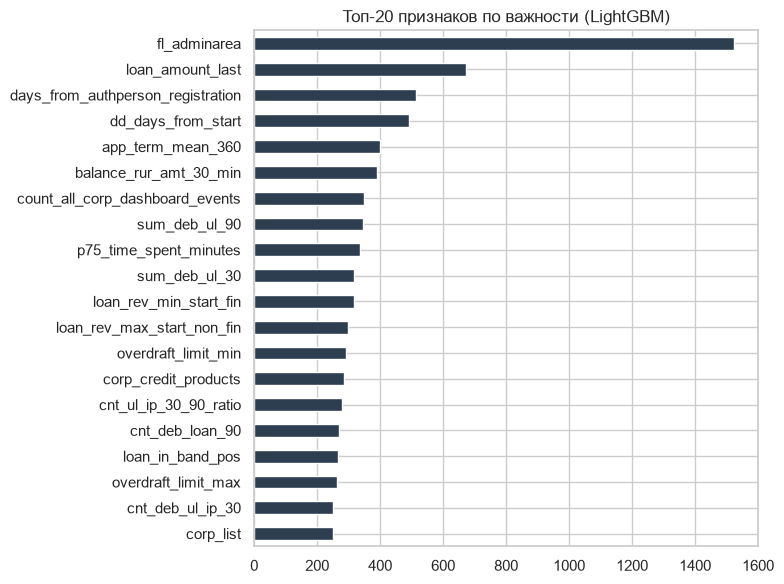

In [14]:
# важности признаков (LightGBM)
imp = pd.Series(lgb_final.feature_importances_, index=FEATURES).sort_values(ascending=False).head(20)
plt.figure(figsize=(8, 6))
imp[::-1].plot.barh(color="#2c3e50")
plt.title("Топ-20 признаков по важности (LightGBM)")
plt.tight_layout(); plt.show()

## 6. Сборка сабмита и проверки

Test-id → предсказание ансамбля; overlap-id (есть в train) → известная метка `target_value`.

In [15]:
test_pred = pd.Series(test_proba, index=test_fe[ID].values, name="p_test")
train_label = train.set_index(ID)[TARGET].astype(float)

sub = sample[[ID]].copy()
sub = sub.merge(test_pred, left_on=ID, right_index=True, how="left")
sub["p_train"] = sub[ID].map(train_label)
sub[TARGET] = sub["p_test"].fillna(sub["p_train"])
sub = sub[[ID, TARGET]]

# --- код-ассерты на корректность сабмита ---
overlap_ids = set(sample[ID]) & set(train[ID])
assert len(sub) == len(sample) == 45032
assert list(sub[ID]) == list(sample[ID])              # порядок/набор id как в шаблоне
assert sub[TARGET].notna().all()                      # нет пропусков
assert sub[TARGET].between(0, 1).all()                # значения в [0,1]
inj = sub.set_index(ID).loc[list(overlap_ids), TARGET]
assert (inj == train.set_index(ID).loc[list(overlap_ids), TARGET].astype(float)).all()
print(f"Проверки пройдены. Строк: {len(sub)} | меток подставлено: {len(overlap_ids)} | "
      f"предсказаний модели: {len(sub) - len(overlap_ids)}")

sub.to_csv("submission.csv", index=False)
print("Сохранено: submission.csv")
sub.head()

Проверки пройдены. Строк: 45032 | меток подставлено: 8721 | предсказаний модели: 36311


Сохранено: submission.csv


,front_id,target_value
0,238459,0.0
1,151533,0.0
2,195027,0.0
3,195034,1.0
4,129620,0.0


## 7. Выводы

- **Стратегия валидации** — по времени (holdout последних месяцев + expanding-window OOF),
  т.к. test лежит в будущем. Holdout-AUC — наиболее честная оценка качества на test.
- **Модель** — ранговый ансамбль трёх бустингов LightGBM + CatBoost + XGBoost (XGBoost дотюнен
  Optuna по OOF). Все нативно обрабатывают пропуски и категории. Урок проекта: ориентир —
  устойчивый OOF, а не одно holdout-окно; но при разнице train/test < ~0.002 AUC ни CV, ни LB
  уже не различимы — мелкие твики не дают надёжного прироста.
- **Признаки** — наибольший вклад дают регион (`fl_adminarea`), запрошенная сумма, давность
  регистрации, время/сезонность, активность клиента и инженерные признаки (спред ставки,
  положение запроса в коридоре лимита, флаги пропусков).
- **Сабмит** — test-id получают предсказание ансамбля, 8 721 overlap-id — известные метки train.
- **Дальнейшие улучшения** — подбор гиперпараметров (Optuna), CV-safe target-encoding регионов,
  добавление XGBoost в ансамбль, калибровка. Загрузки на платформу — не более 3/сутки.